Initial Shape: (541909, 8)
Cleaned Shape: (397884, 11)


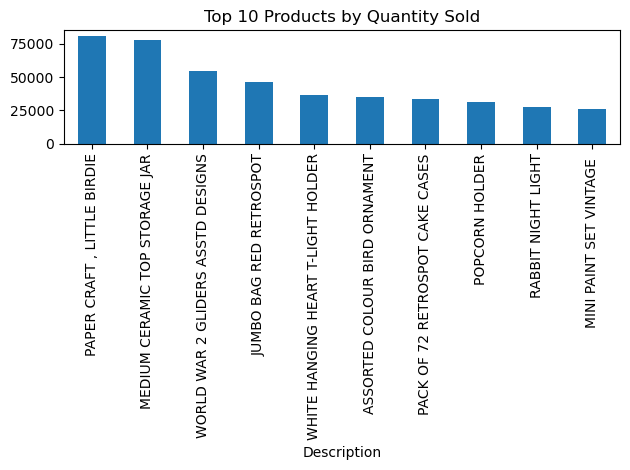

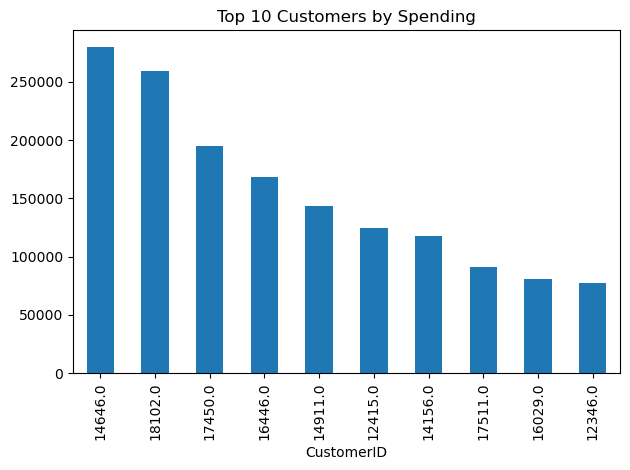

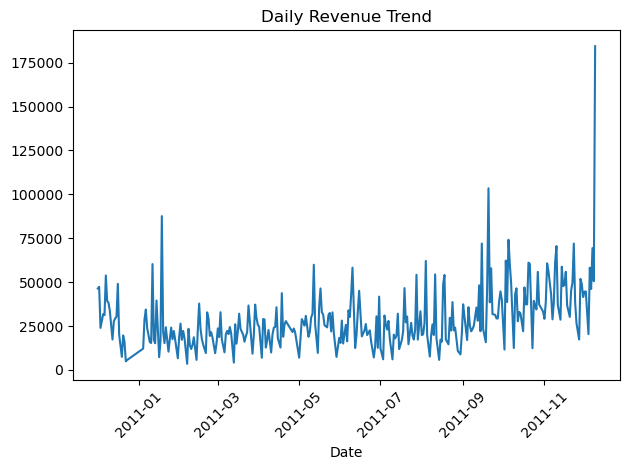

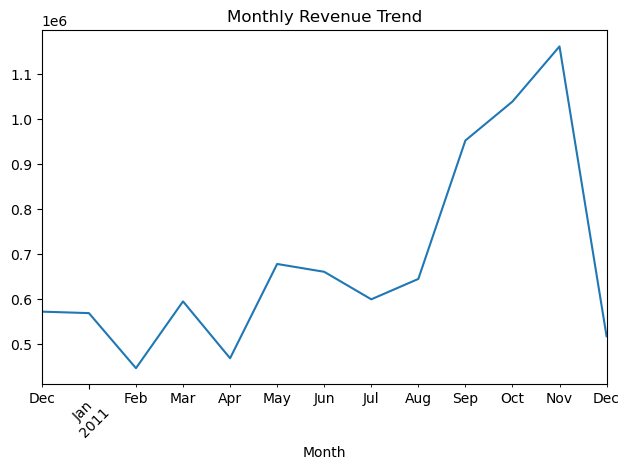

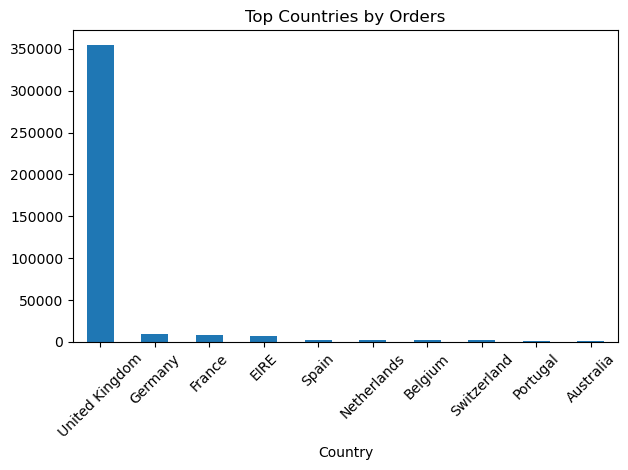

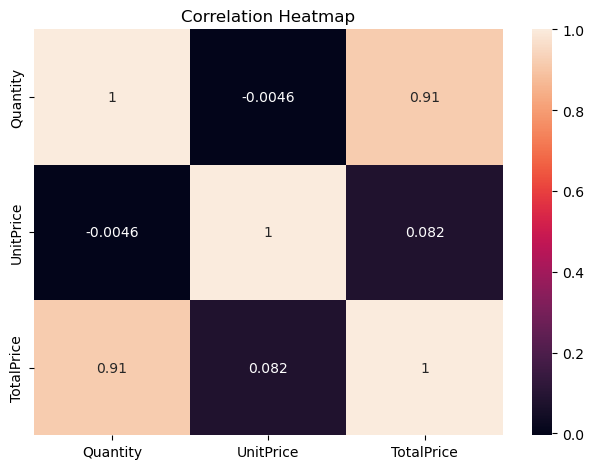

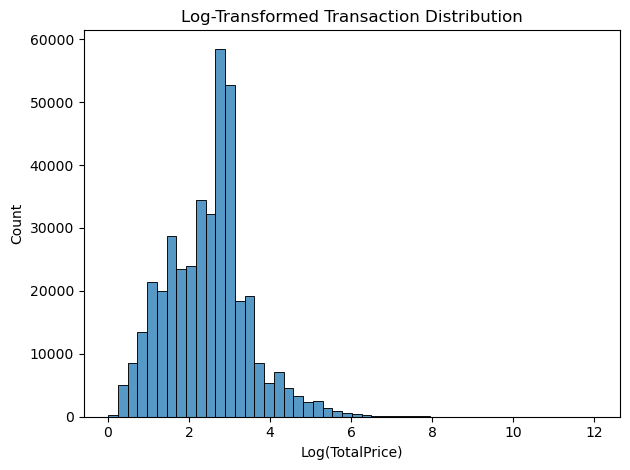

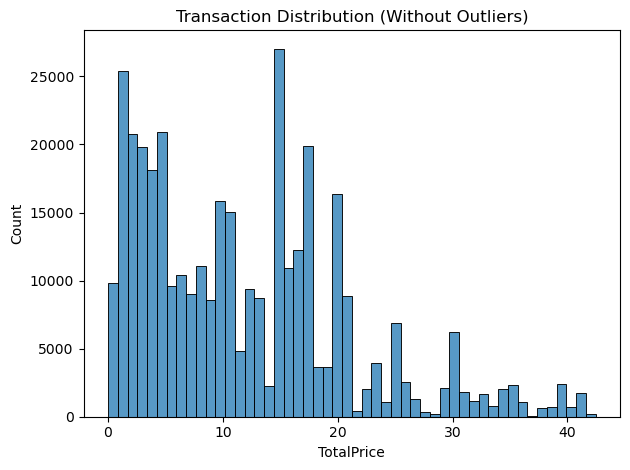

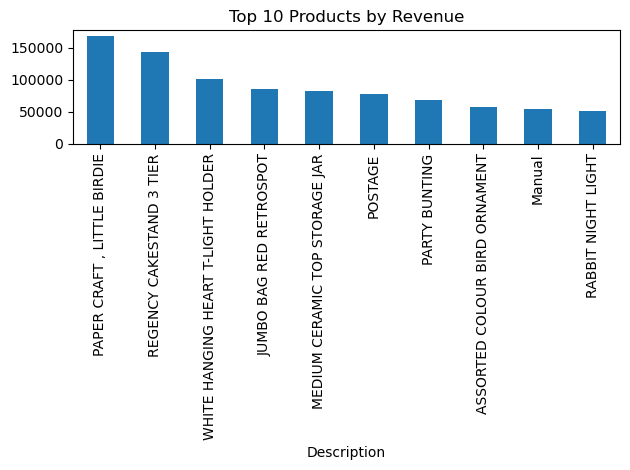


===== KEY BUSINESS INSIGHTS =====

1. Top Country: United Kingdom
2. Most Sold Product: PAPER CRAFT , LITTLE BIRDIE
3. Highest Revenue Product: PAPER CRAFT , LITTLE BIRDIE
4. Top Customer: 14646.0
5. Peak Sales Date: 2011-12-09
6. Total Revenue: 8911407.9
7. Avg Transaction Value: 22.4
8. Unique Customers: 4338



All outputs saved in: F:\OUTRIX Data\outputs


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


output_folder = r"F:\OUTRIX Data\outputs"
os.makedirs(output_folder, exist_ok=True)

file_path = r"F:\OUTRIX Data\data.csv"
df = pd.read_csv(file_path, encoding='latin1')

print("Initial Shape:", df.shape)


# Data Cleaning

df = df.dropna(subset=['CustomerID']).copy()
df['Description'] = df['Description'].fillna("Unknown")

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Feature Engineering
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Date'] = df['InvoiceDate'].dt.date
df['Month'] = df['InvoiceDate'].dt.to_period('M')

print("Cleaned Shape:", df.shape)

# Save cleaned dataset
df.to_csv(os.path.join(output_folder, "cleaned_data.csv"), index=False)


# Customer Analysis

top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)


# Product Analysis

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_revenue_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)


# Time Analysis

daily_sales = df.groupby('Date')['TotalPrice'].sum()
monthly_sales = df.groupby('Month')['TotalPrice'].sum()


# RFM Analysis

snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.to_csv(os.path.join(output_folder, "rfm_analysis.csv"))


# VISUALIZATIONS


# 1. Top Products
plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Quantity Sold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_products.png"))
plt.show()

# 2. Top Customers
plt.figure()
top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_customers.png"))
plt.show()

# 3. Daily Revenue
plt.figure()
daily_sales.plot()
plt.title("Daily Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "daily_revenue.png"))
plt.show()

# 4. Monthly Revenue
plt.figure()
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "monthly_revenue.png"))
plt.show()

# 5. Top Countries
plt.figure()
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top Countries by Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_countries.png"))
plt.show()

# 6. Correlation Heatmap
plt.figure()
sns.heatmap(df[['Quantity', 'UnitPrice', 'TotalPrice']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "correlation_heatmap.png"))
plt.show()


# 7. Log-Transformed Distribution (BEST)
plt.figure()
sns.histplot(np.log1p(df['TotalPrice']), bins=50)
plt.title("Log-Transformed Transaction Distribution")
plt.xlabel("Log(TotalPrice)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "distribution_log.png"))
plt.show()

# 8. Distribution without Outliers
q1 = df['TotalPrice'].quantile(0.25)
q3 = df['TotalPrice'].quantile(0.75)
iqr = q3 - q1

filtered_df = df[
    (df['TotalPrice'] >= q1 - 1.5 * iqr) &
    (df['TotalPrice'] <= q3 + 1.5 * iqr)
]

plt.figure()
sns.histplot(filtered_df['TotalPrice'], bins=50)
plt.title("Transaction Distribution (Without Outliers)")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "distribution_no_outliers.png"))
plt.show()

# 9. Top Revenue Products
plt.figure()
top_revenue_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "top_revenue_products.png"))
plt.show()


# INSIGHTS

insights = f"""
===== KEY BUSINESS INSIGHTS =====

1. Top Country: {df['Country'].value_counts().idxmax()}
2. Most Sold Product: {top_products.idxmax()}
3. Highest Revenue Product: {top_revenue_products.idxmax()}
4. Top Customer: {top_customers.idxmax()}
5. Peak Sales Date: {daily_sales.idxmax()}
6. Total Revenue: {round(df['TotalPrice'].sum(), 2)}
7. Avg Transaction Value: {round(df['TotalPrice'].mean(), 2)}
8. Unique Customers: {df['CustomerID'].nunique()}

"""

print(insights)

with open(os.path.join(output_folder, "insights.txt"), "w") as f:
    f.write(insights)

print(f"\nAll outputs saved in: {output_folder}")